<a href="https://colab.research.google.com/github/mailan48692004-web/Climate-Risk-Monitoring-and-Site-Prioritisation/blob/main/notebooks/E_commerce_Business_Performance_and_Strategic_Improvement_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Business Performance and Strategic Improvement Analysis

## Executive Summary

This project evaluates the performance of an e-commerce business using order, payment, customer, and product data. The aim is not only to describe historical patterns, but to identify commercially relevant insights that can support stronger business decisions.

The analysis focuses on four key questions: how the business is performing over time, which commercial drivers are contributing most to results, what customer and revenue patterns suggest about business quality, and what short-term demand signals imply for planning.

Overall, the project is designed as a business performance review rather than a purely technical exercise. The emphasis is on translating data into practical implications for growth, customer experience, and operational effectiveness.

## 1. Business Context and Objectives

E-commerce businesses generate large volumes of transactional and customer data, but raw data alone does not explain whether performance is improving in a meaningful way, where value is being created, or which issues may constrain future growth. To support better decision-making, analysis needs to move beyond simple reporting and assess the business from a more commercial perspective.

This project approaches the dataset as a decision-support problem. The objective is to examine business performance, identify meaningful revenue and customer patterns, and translate findings into practical recommendations that management could use to improve performance.

The analysis is guided by the following objectives:

- assess overall business performance using core sales and order indicators  
- identify important commercial drivers, including category-level performance patterns  
- examine customer behaviour to better understand repeat activity and revenue quality  
- review operational and demand signals that may affect planning and customer experience  
- generate practical recommendations for business improvement and strategic focus

## 2. Dataset and Scope

This analysis uses multiple e-commerce tables, including orders, order items, payments, customers, products, and category translations. Together, these tables provide a broader view of how the business performs across transactions, customer activity, and product mix.

Each dataset supports a different part of the business review:

- **orders** provide information about order flow and timing  
- **order items** help evaluate sales contribution and category patterns  
- **payments** provide insight into transaction behaviour  
- **customers** support customer-level and repeat-purchase analysis  
- **products / category translation** allow product and category performance to be interpreted more clearly  

The main analytical scope focuses on completed or delivered activity so that performance patterns are based on transactions that progressed through the business successfully.

Because the dataset does not contain full cost, margin, or external market data, conclusions should be interpreted as commercially useful but not equivalent to a full valuation, profitability model, or due diligence assessment.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [9]:
orders = pd.read_csv('/content/sample_data/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/sample_data/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/sample_data/olist_order_payments_dataset.csv')
products = pd.read_csv('/content/sample_data/olist_products_dataset.csv')
customers = pd.read_csv('/content/sample_data/olist_customers_dataset.csv')
cat_trans = pd.read_csv('/content/sample_data/product_category_name_translation.csv')

In [10]:
tables = {
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "products": products,
    "customers": customers,
    "cat_trans": cat_trans
}

for name, df in tables.items():
    print(f"\n=== {name.upper()} ===")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values (top 10):")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    print("\nSample:")
    display(df.head(3))


=== ORDERS ===
Shape: (99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Missing values (top 10):
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

Sample:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



=== ORDER_ITEMS ===
Shape: (112650, 7)

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Missing values (top 10):
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Sample:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



=== PAYMENTS ===
Shape: (103886, 5)

Columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Missing values (top 10):
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Sample:


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



=== CUSTOMERS ===
Shape: (99441, 5)

Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Missing values (top 10):
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Sample:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



=== CAT_TRANS ===
Shape: (71, 2)

Columns:
['product_category_name', 'product_category_name_english']

Missing values (top 10):
product_category_name            0
product_category_name_english    0
dtype: int64

Sample:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


## 3. Data Preparation and Reliability Checks

Before interpreting business performance, the data must first be prepared into a structure suitable for reliable analysis. This is especially important in multi-table e-commerce datasets, where one-to-many relationships can distort results if revenue, order counts, or customer measures are aggregated incorrectly.

The preparation stage focuses on building an order-level analytical base that can support clearer performance assessment. This includes cleaning date fields, filtering relevant transactions, aggregating item and payment information where necessary, and joining datasets in a way that preserves business meaning.

In addition to data preparation, basic reliability checks are included to reduce the risk of drawing conclusions from duplicate records, missing values, or fragmented transaction structures. This step improves confidence that subsequent findings reflect business patterns rather than technical artefacts in the raw data.

### Data Preparation and Merging

In [11]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["order_status"].value_counts(dropna=False)

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [12]:
orders_delivered = orders[orders["order_status"] == "delivered"].copy()
print("Delivered orders shape:", orders_delivered.shape)

Delivered orders shape: (96478, 8)


In [13]:
payment_by_order = (
    payments.groupby("order_id", as_index=False)
    .agg(
        payment_value_total=("payment_value", "sum"),
        payment_installments_max=("payment_installments", "max"),
        payment_sequential_count=("payment_sequential", "count")
    )
)

payment_by_order.head()

,order_id,payment_value_total,payment_installments_max,payment_sequential_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


In [14]:
items_by_order = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        item_price_total=("price", "sum"),
        freight_total=("freight_value", "sum")
    )
)

items_by_order.head()

,order_id,item_count,item_price_total,freight_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


In [15]:
order_level = (
    orders_delivered
    .merge(customers, on="customer_id", how="left")
    .merge(payment_by_order, on="order_id", how="left")
    .merge(items_by_order, on="order_id", how="left")
)

print(order_level.shape)
order_level.head()

(96478, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value_total,payment_installments_max,payment_sequential_count,item_count,item_price_total,freight_total
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,3.0,1,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,1.0,1,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,1.0,1,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,1.0,1,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,1.0,1,19.90,8.72


In [16]:
order_level["order_date"] = order_level["order_purchase_timestamp"].dt.date
order_level["order_month"] = order_level["order_purchase_timestamp"].dt.to_period("M").astype(str)
order_level["order_week"] = order_level["order_purchase_timestamp"].dt.to_period("W").astype(str)
order_level["order_year_month"] = order_level["order_purchase_timestamp"].dt.to_period("M")
order_level["order_value"] = order_level["payment_value_total"]

### Feature Construction


In [17]:
customer_order_counts = (
    order_level.groupby("customer_unique_id", as_index=False)
    .agg(total_orders=("order_id", "nunique"))
)

order_level = order_level.merge(customer_order_counts, on="customer_unique_id", how="left")

order_level["customer_type"] = np.where(order_level["total_orders"] > 1, "Repeat", "One-time")

In [18]:
first_purchase = (
    order_level.groupby("customer_unique_id", as_index=False)
    .agg(first_purchase_ts=("order_purchase_timestamp", "min"))
)

order_level = order_level.merge(first_purchase, on="customer_unique_id", how="left")
order_level["first_purchase_month"] = order_level["first_purchase_ts"].dt.to_period("M").astype(str)

In [19]:
products = products.merge(
    cat_trans,
    on="product_category_name",
    how="left"
)

order_item_level = (
    order_items
    .merge(
        products[["product_id", "product_category_name", "product_category_name_english"]],
        on="product_id",
        how="left"
    )
    .merge(
        orders_delivered[["order_id", "customer_id", "order_purchase_timestamp"]],
        on="order_id",
        how="inner"
    )
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
)

order_item_level["order_month"] = order_item_level["order_purchase_timestamp"].dt.to_period("M").astype(str)
order_item_level["order_week"] = order_item_level["order_purchase_timestamp"].dt.to_period("W").astype(str)
order_item_level["item_revenue"] = order_item_level["price"] + order_item_level["freight_value"]

print(order_item_level.shape)
order_item_level.head()

(110197, 15)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,customer_id,order_purchase_timestamp,customer_unique_id,order_month,order_week,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,2017-09,2017-09-11/2017-09-17,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,2017-04,2017-04-24/2017-04-30,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,2018-01,2018-01-08/2018-01-14,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,2018-08,2018-08-06/2018-08-12,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,2017-02,2017-01-30/2017-02-05,218.04


### Reliability Checks


In [20]:
print("Order-level shape:", order_level.shape)
print("Order-item-level shape:", order_item_level.shape)

print("Duplicate order_id in order_level:", order_level["order_id"].duplicated().sum())
print("Missing order_value ratio:", order_level["order_value"].isna().mean())
print("Missing English category ratio:", order_item_level["product_category_name_english"].isna().mean())

Order-level shape: (96478, 27)
Order-item-level shape: (110197, 15)
Duplicate order_id in order_level: 0
Missing order_value ratio: 1.0365057318766973e-05
Missing English category ratio: 0.014147390582320753


## 4. Analytical Framework

To make the analysis more decision-oriented, the business is reviewed through four lenses:

1. **Business performance**  
   Examining overall order and revenue trends to understand scale, momentum, and recent movement.

2. **Commercial drivers**  
   Identifying which categories or parts of the business contribute most strongly to performance and where concentration may exist.

3. **Customer mix and revenue quality**  
   Assessing customer behaviour, including repeat activity, to understand whether performance appears broad-based or dependent on less stable patterns.

4. **Operational and demand signals**  
   Reviewing timing, weekly movement, and short-term forecasting to consider how performance translates into planning and execution.

This framework helps ensure that the project remains focused on commercial interpretation rather than isolated technical outputs.

## 5. Business Performance Review

This section evaluates overall business performance using core indicators such as orders, revenue, and trend movement over time. The purpose is to establish a baseline view of how the business is performing before moving into more detailed category and customer analysis.

The key question here is not only whether activity is rising or falling, but whether the pattern suggests stable growth, volatility, concentration, or possible pressure points that management should monitor more closely.

### KPI Overview

In [21]:
total_orders = order_level["order_id"].nunique()
total_revenue = order_level["order_value"].sum()
aov = order_level["order_value"].mean()
repeat_rate = (order_level["customer_type"] == "Repeat").mean()

print("Total orders:", total_orders)
print("Total revenue:", round(total_revenue, 2))
print("Average order value:", round(aov, 2))
print("Repeat customer rate:", round(repeat_rate, 4))

Total orders: 96478
Total revenue: 15422461.77
Average order value: 159.86
Repeat customer rate: 0.0614




- The dataset captures a meaningful level of commercial activity, with over 96,000 delivered orders and total order value above 15 million.
- Average order value is relatively stable at an aggregate level, suggesting that overall revenue growth is likely to be driven more by changes in order volume than by large movements in basket size.
- The repeat customer rate is low at approximately 6%, which suggests the business may rely heavily on one-time purchases. However, this should be interpreted cautiously, as repeat behaviour may also be influenced by the available observation window and category purchasing cycles.

### Revenue Trend Over Time


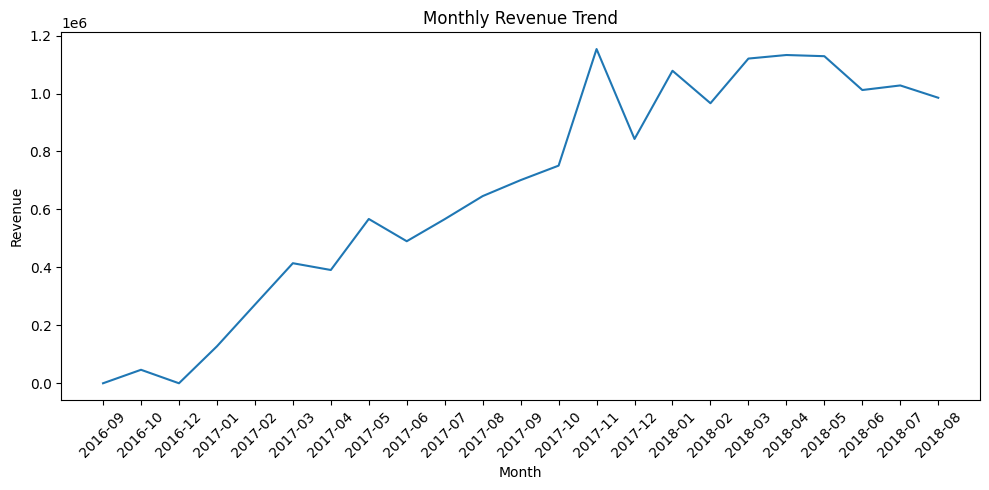

In [22]:
monthly_trend = (
    order_level.groupby("order_year_month", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum")
    )
    .sort_values("order_year_month")
)

monthly_trend["order_year_month_str"] = monthly_trend["order_year_month"].astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_trend["order_year_month_str"], monthly_trend["revenue"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Business interpretation:**  
These results provide an overall view of business momentum. From a decision-making perspective, the main issue is whether recent performance reflects sustainable activity or whether additional investigation is needed into volatility, seasonality, or slowing growth.



- Monthly revenue and order volume both show a clear upward trend over time, indicating overall business growth during the observed period.
- The growth pattern is not perfectly smooth, with several fluctuations and spikes that may reflect seasonality, campaigns, assortment changes, or operational factors.
- Because growth appears to be driven by volume as well as timing effects, short-term performance should be interpreted with both trend and business context in mind.

## 6. Commercial Drivers: Category Performance

A business may appear to perform well in aggregate while still relying heavily on a limited number of categories or sales drivers. For that reason, category-level analysis is important for understanding where commercial strength is concentrated and whether performance is broadly diversified.

This section examines which categories contribute most to revenue or order activity and whether the current mix suggests clear growth engines, underperforming areas, or possible concentration risk. From a Corporate Advisory perspective, this kind of analysis is useful because business quality depends not only on total sales, but also on the composition and resilience of those sales.

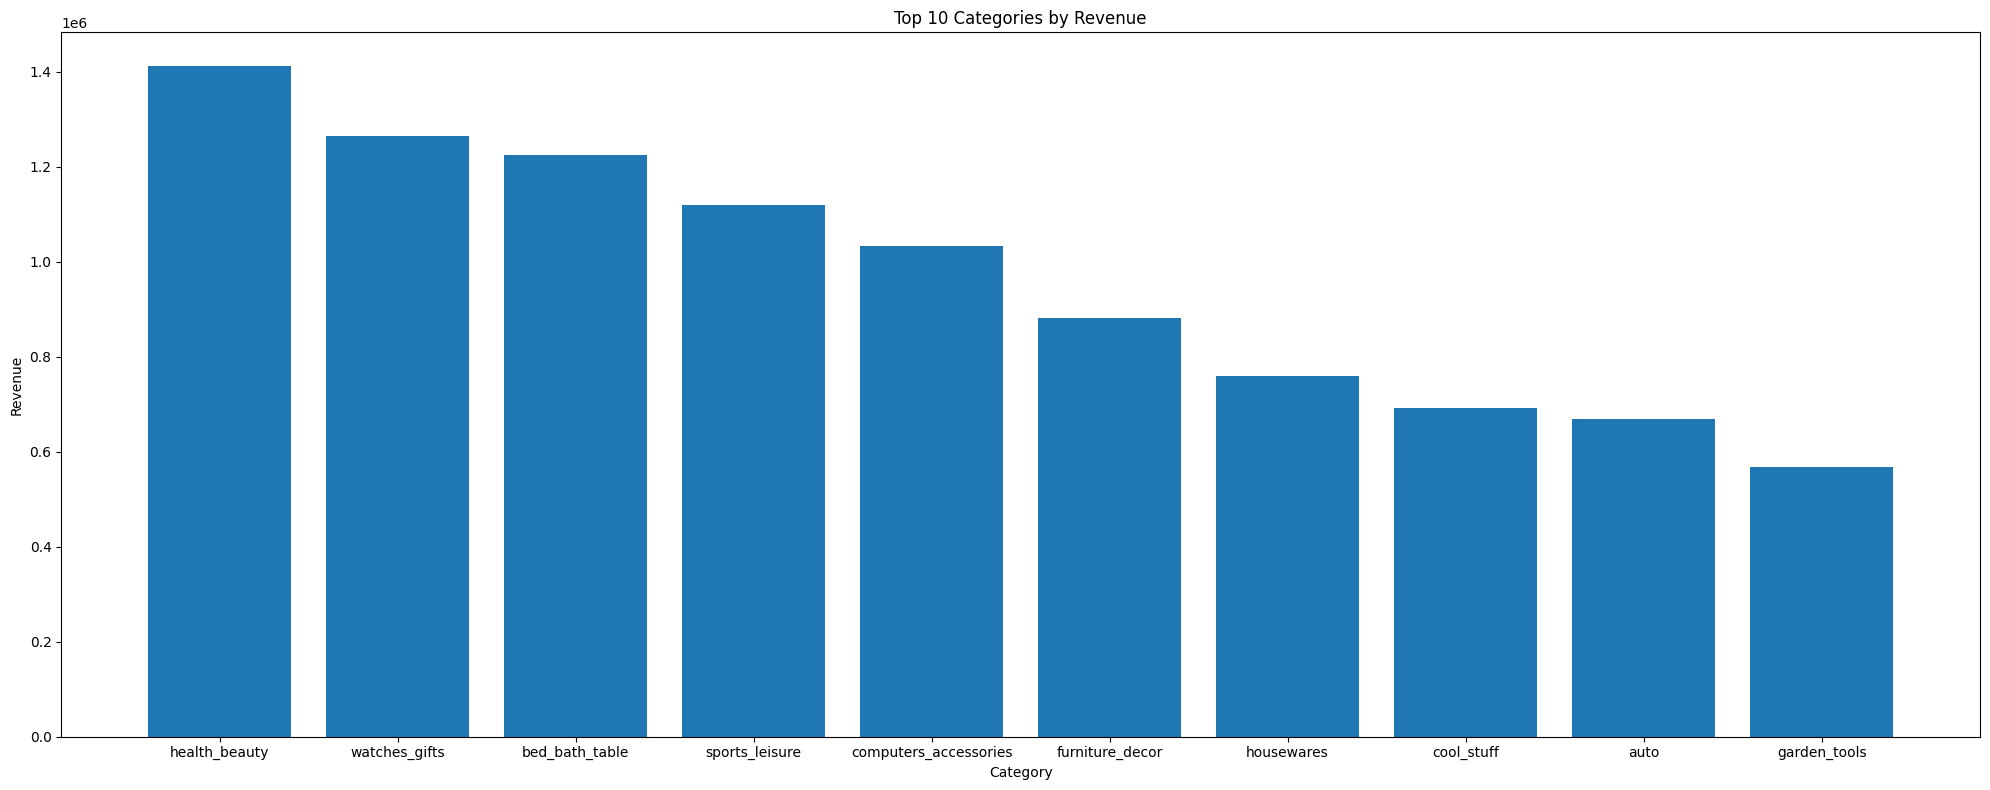

,product_category_name_english,orders,revenue
43,health_beauty,8647,1412089.53
70,watches_gifts,5495,1264333.12
7,bed_bath_table,9272,1225209.26
65,sports_leisure,7530,1118256.91
15,computers_accessories,6530,1032723.77
39,furniture_decor,6307,880329.92
49,housewares,5743,758392.25
20,cool_stuff,3559,691680.89
5,auto,3810,669454.75
42,garden_tools,3448,567145.68


In [23]:
top_categories = (
    order_item_level.groupby("product_category_name_english", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("item_revenue", "sum")
    )
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(20, 8))
plt.bar(top_categories["product_category_name_english"], top_categories["revenue"])
plt.xticks(rotation=0)
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

top_categories

**Business interpretation:**  
Category performance helps identify where the business is strongest and where it may be overly reliant on a narrow set of drivers. This matters because stronger concentration can increase commercial risk even when top-line results appear healthy.



- Revenue appears concentrated in a relatively small number of product categories, including health and beauty, watches and gifts, and bed, bath, and table.
- This concentration suggests the business has identifiable category leaders that likely play a disproportionate role in total commercial performance.
- While category concentration can support focused commercial strategy, it also introduces risk if demand weakens in a small number of core categories. Category-level monitoring is therefore important for both growth and resilience.

## 7. Customer Mix and Revenue Quality

Understanding customer behaviour is important for evaluating the quality of business performance. Revenue generated from repeat customers may indicate stronger retention and customer value, while heavy dependence on one-time purchases may suggest a different growth profile and different strategic priorities.

This section examines customer activity patterns to assess how revenue is supported, whether repeat behaviour appears meaningful, and what that may imply for customer experience, retention, and long-term performance quality.

In [24]:
segment_summary = (
    order_level.groupby("customer_type", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum"),
        aov=("order_value", "mean")
    )
)

segment_summary

,customer_type,customers,orders,revenue,aov
0,One-time,90557,90557,14558104.56,160.763556
1,Repeat,2801,5921,864357.21,145.981626


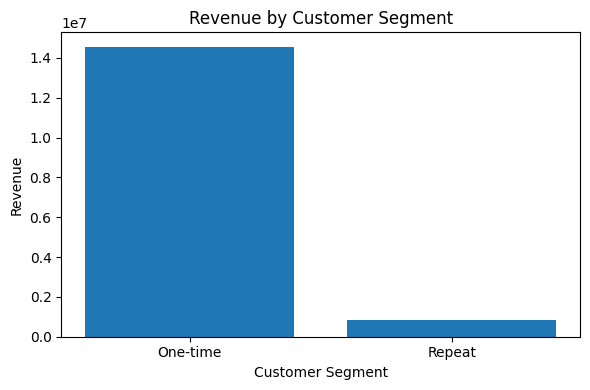

In [25]:
plt.figure(figsize=(6, 4))
plt.bar(segment_summary["customer_type"], segment_summary["revenue"])
plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Business interpretation:**  
Customer mix provides insight into the quality and sustainability of revenue. A stronger repeat-customer base may support more efficient growth, while a one-time heavy structure may require greater emphasis on acquisition, conversion, or retention improvement.



- One-time customers account for the overwhelming majority of customers and orders in the dataset, while repeat customers contribute a much smaller share of business activity.
- This indicates that the business may currently depend more on acquisition and first-time conversion than on sustained repeat purchasing behaviour.
- Repeat customer value should not be judged using headline counts alone. A more useful next step would be to examine repeat behaviour by product category, customer value tier, or first-purchase cohort to identify where retention opportunities are strongest.

## 8. Operational and Demand Signals

Beyond revenue and customer mix, business performance is also shaped by execution. Weekly variation, shifts across periods, and short-term movement in order activity can all affect planning, service quality, and management responsiveness.

This section reviews demand patterns and operational signals that may help explain recent performance or support better short-term planning. The goal is not to overstate forecasting precision, but to use timing patterns as an additional input for understanding business conditions and potential decision needs.

In [26]:
monthly_trend[["order_year_month_str", "orders", "revenue"]]

,order_year_month_str,orders,revenue
0,2016-09,1,0.00
1,2016-10,265,46566.71
2,2016-12,1,19.62
3,2017-01,750,127545.67
4,2017-02,1653,271298.65
5,2017-03,2546,414369.39
6,2017-04,2303,390952.18
7,2017-05,3546,567066.73
8,2017-06,3135,490225.60
9,2017-07,3872,566403.93


In [27]:
cutoff_month = "2017-11"

pre_post = (
    order_level.assign(period=np.where(order_level["order_month"] < cutoff_month, "Before", "After"))
    .groupby("period", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
        repeat_order_share=("customer_type", lambda x: (x == "Repeat").mean())
    )
)

pre_post

,period,orders,revenue,avg_order_value,repeat_order_share
0,After,65585,10449702.42,159.330677,0.055226
1,Before,30893,4972759.35,160.972399,0.074418




- The post-cutoff period shows materially higher order volume and revenue than the earlier period, indicating that the business expanded significantly over time.
- Average order value changed less dramatically than total orders and revenue, which suggests that growth was driven more by increased transaction volume than by a major increase in spend per order.
- Repeat order share appears lower in the later period, which may indicate that growth was supported more by customer acquisition or broader demand expansion than by stronger repeat purchasing.
- This comparison is directional only and should be treated as an exploratory performance shift analysis rather than evidence of a causal business intervention.

## 9. Short-Term Forecasting for Planning

This section uses short-term forecasting as a directional planning tool rather than a precise predictive exercise. The objective is to provide a forward-looking view of demand that may help with short-term planning for fulfilment, staffing, or operational monitoring.

Forecast results are interpreted cautiously. In this context, the main value of forecasting lies less in exact precision and more in highlighting unusual variation, changing momentum, or periods that may require closer management attention.

In [28]:
weekly_demand = (
    order_level.set_index("order_purchase_timestamp")
    .resample("W")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_value", "sum")
    )
    .reset_index()
)

weekly_demand.head()

,order_purchase_timestamp,orders,revenue
0,2016-09-18,1,0.00
1,2016-09-25,0,0.00
2,2016-10-02,0,0.00
3,2016-10-09,231,42669.98
4,2016-10-16,34,3896.73


In [29]:
ts = weekly_demand[["order_purchase_timestamp", "orders"]].dropna().copy()
ts = ts.set_index("order_purchase_timestamp")

train = ts.iloc[:-8]
test = ts.iloc[-8:]

model_results = []

configs = [
    {"name": "Trend only", "trend": "add", "seasonal": None, "seasonal_periods": None},
    {"name": "Trend + Seasonality (4)", "trend": "add", "seasonal": "add", "seasonal_periods": 4},
    {"name": "Trend + Seasonality (8)", "trend": "add", "seasonal": "add", "seasonal_periods": 8},
    {"name": "Trend + Seasonality (12)", "trend": "add", "seasonal": "add", "seasonal_periods": 12},
]

best_model = None
best_pred = None
best_name = None
best_mape = float("inf")

for cfg in configs:
    try:
        model = ExponentialSmoothing(
            train["orders"],
            trend=cfg["trend"],
            seasonal=cfg["seasonal"],
            seasonal_periods=cfg["seasonal_periods"]
        ).fit(optimized=True)

        pred = model.forecast(len(test))

        mae = mean_absolute_error(test["orders"], pred)
        mape = mean_absolute_percentage_error(test["orders"], pred)

        model_results.append({
            "model": cfg["name"],
            "MAE": mae,
            "MAPE": mape
        })

        if mape < best_mape:
            best_mape = mape
            best_model = model
            best_pred = pred
            best_name = cfg["name"]

    except Exception as e:
        model_results.append({
            "model": cfg["name"],
            "MAE": np.nan,
            "MAPE": np.nan
        })

results_df = pd.DataFrame(model_results).sort_values("MAPE")
results_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


,model,MAE,MAPE
3,Trend + Seasonality (12),465.830671,1.397273
0,Trend only,550.479788,1.544104
1,Trend + Seasonality (4),562.162628,1.550008
2,Trend + Seasonality (8),632.304259,1.590806


In [30]:
forecast_results = test.copy()
forecast_results["forecast_orders"] = pred.values
forecast_results["abs_error"] = (forecast_results["orders"] - forecast_results["forecast_orders"]).abs()

forecast_results

,orders,forecast_orders,abs_error
order_purchase_timestamp,,,
2018-07-15,972,1217.584398,245.584398
2018-07-22,1649,1267.263188,381.736812
2018-07-29,1610,1284.632215,325.367785
2018-08-05,2002,1546.708199,455.291801
2018-08-12,1931,1445.006024,485.993976
2018-08-19,1839,1293.995328,545.004672
2018-08-26,1054,1234.409270,180.409270
2018-09-02,116,1223.256652,1107.256652


Best model: Trend + Seasonality (12)
Best MAE: 465.83
Best MAPE: 1.3973


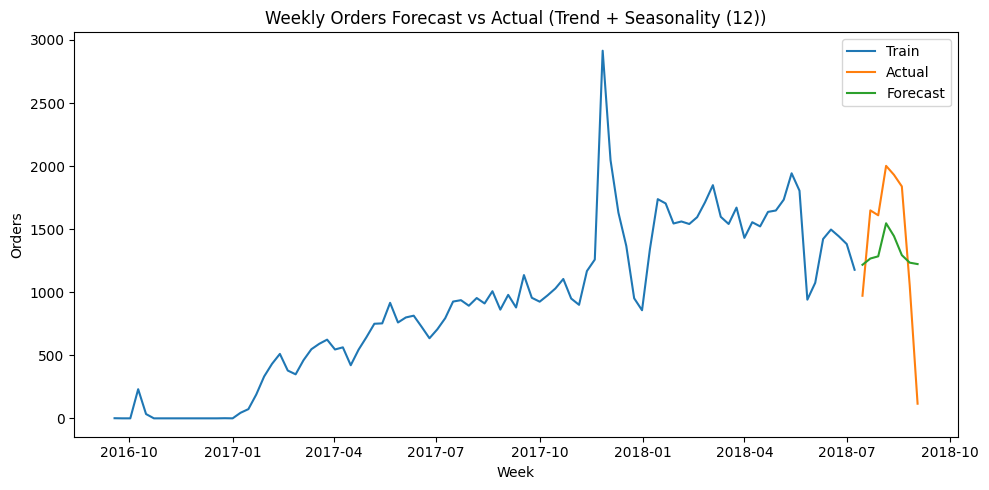

In [31]:
forecast_results = test.copy()
forecast_results["forecast_orders"] = best_pred.values
forecast_results["abs_error"] = (forecast_results["orders"] - forecast_results["forecast_orders"]).abs()

print("Best model:", best_name)
print("Best MAE:", round(mean_absolute_error(test["orders"], best_pred), 2))
print("Best MAPE:", round(mean_absolute_percentage_error(test["orders"], best_pred), 4))

plt.figure(figsize=(10, 5))
plt.plot(train.index, train["orders"], label="Train")
plt.plot(test.index, test["orders"], label="Actual")
plt.plot(test.index, forecast_results["forecast_orders"], label="Forecast")
plt.legend()
plt.title(f"Weekly Orders Forecast vs Actual ({best_name})")
plt.xlabel("Week")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

**Business interpretation:**  
The forecast should be viewed as a planning aid rather than a precise prediction. Large deviations may indicate changing demand conditions, unusual volatility, or operational factors that would warrant closer management attention.


- Weekly orders show both a strong upward trend and noticeable short-term volatility.
- The seasonal model provides a more realistic forecast profile than a simple trend-only baseline and captures the overall demand level reasonably well.
- However, some forecast gaps remain in weeks with sharper demand swings, suggesting that weekly performance is influenced by business factors beyond trend and seasonality alone.
- This means the forecast is useful as a short-term planning baseline, but should be combined with business context and exception review.

### Forecast Exception Review


In [32]:
largest_errors = forecast_results.sort_values("abs_error", ascending=False).head(5)
largest_errors

,orders,forecast_orders,abs_error
order_purchase_timestamp,,,
2018-09-02,116,1223.256652,1107.256652
2018-08-19,1839,1293.995328,545.004672
2018-08-12,1931,1445.006024,485.993976
2018-08-05,2002,1546.708199,455.291801
2018-07-22,1649,1267.263188,381.736812




- The largest forecast errors occur in a limited number of weeks, rather than being evenly distributed across the holdout period.
- This pattern suggests that forecast misses may be linked to business-specific exceptions or temporary demand shocks rather than to a complete failure of the underlying forecasting approach.
- In practice, these high-error weeks should be reviewed alongside commercial and operational context to determine whether they reflect promotional activity, external events, reporting issues, or genuine shifts in customer demand.

## 10. Strategic Implications

Taken together, the findings from performance, category, customer, and demand analysis provide a broader view of the business than any single KPI can offer. The main value of this project lies in connecting those findings to management implications.

Several strategic questions emerge from the analysis:

- Is current growth broad-based or dependent on a narrow set of commercial drivers?  
- Does customer behaviour suggest stronger retention potential or continued reliance on one-time activity?  
- Are there operational signals that could affect service quality, execution consistency, or short-term planning?  
- Which issues appear most relevant for management attention if the goal is to improve both growth and business quality?  

These implications matter because business decisions are rarely based on one metric alone. More useful judgement comes from understanding how revenue, customer behaviour, and operations interact.

## 11. Recommendations

Based on the analysis, the following recommendations are proposed.

### A. Growth and Commercial Focus
- Prioritise the categories or segments that show the clearest contribution to business performance.  
- Assess whether growth is diversified enough or whether dependence on a small number of drivers creates commercial vulnerability.  
- Use category and customer insights to guide where management should focus promotional, retention, or expansion efforts.

### B. Customer and Experience Improvement
- Monitor repeat versus one-time customer patterns more closely to better understand customer quality and retention opportunities.  
- Investigate whether observed behavioural patterns point to friction in the customer journey, payment experience, or post-purchase process.  
- Use customer insights not only for reporting, but to support targeted actions that improve retention and lifetime value.

### C. Operational and Planning Discipline
- Use weekly demand and forecast signals as inputs for short-term planning rather than relying solely on historical averages.  
- Monitor periods of unusual deviation more closely, as these may indicate operational bottlenecks or shifting customer conditions.  
- Build a regular KPI review process that combines performance, customer, and operational measures rather than treating them separately.

## 12. Limitations and Next Steps

This analysis provides a commercially useful view of business performance, but it also has important limitations. The dataset does not include full cost structures, profit margins, marketing spend, inventory constraints, or external competitive benchmarks. As a result, the recommendations should be interpreted as decision-support insights rather than complete strategic conclusions.

Possible next steps include:

- incorporating margin or cost data to move from revenue analysis to profitability analysis  
- adding cohort or retention analysis for a deeper view of customer value  
- evaluating performance by geography, customer segment, or fulfilment characteristics  
- comparing internal results with external market benchmarks where available  

These additions would strengthen the business case and support more advanced strategic assessment.